In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load processed data
matches = pd.read_csv("../data/processed/matches.csv")
finished = pd.read_csv("../data/processed/matches_finished.csv")
standings = pd.read_csv("../data/processed/standings.csv")
scorers = pd.read_csv("../data/processed/scorers.csv")

matches.head()

,match_id,utc_date,status,matchday,home_team_id,home_team,away_team_id,away_team,ft_home,ft_away,season_label,total_goals,goal_diff_home,result,date,year,month
0,435943,2023-08-11 19:00:00+00:00,FINISHED,1,328,Burnley FC,65,Manchester City FC,0.0,3.0,2023,3.0,-3.0,A,2023-08-11,2023,8
1,435944,2023-08-12 12:00:00+00:00,FINISHED,1,57,Arsenal FC,351,Nottingham Forest FC,2.0,1.0,2023,3.0,1.0,H,2023-08-12,2023,8
2,435945,2023-08-12 14:00:00+00:00,FINISHED,1,1044,AFC Bournemouth,563,West Ham United FC,1.0,1.0,2023,2.0,0.0,D,2023-08-12,2023,8
3,435946,2023-08-12 14:00:00+00:00,FINISHED,1,397,Brighton & Hove Albion FC,389,Luton Town FC,4.0,1.0,2023,5.0,3.0,H,2023-08-12,2023,8
4,435947,2023-08-12 14:00:00+00:00,FINISHED,1,62,Everton FC,63,Fulham FC,0.0,1.0,2023,1.0,-1.0,A,2023-08-12,2023,8


In [5]:
print("Matches shape:", matches.shape)
print("Finished shape:", finished.shape)
print("Standings shape:", standings.shape)
print("Scorers shape:", scorers.shape)

Matches shape: (1520, 17)
Finished shape: (1340, 17)
Standings shape: (80, 13)
Scorers shape: (40, 8)


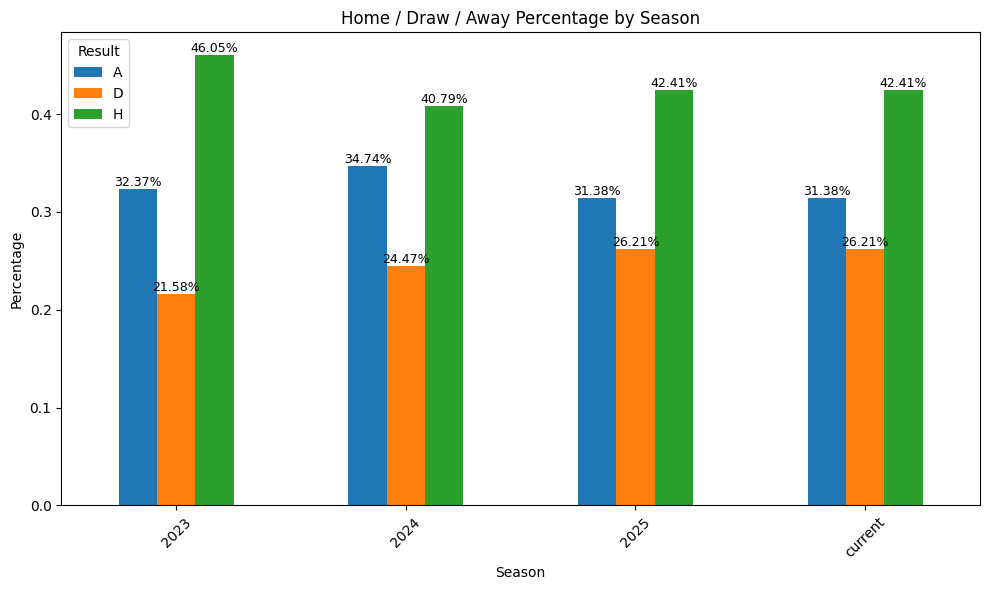

In [7]:
# Home / Draw / Away distribution by season (with labels)

result_dist = (
    finished.groupby(["season_label", "result"])
    .size()
    .unstack(fill_value=0)
)

result_pct = result_dist.div(result_dist.sum(axis=1), axis=0)

ax = result_pct.plot(kind="bar", figsize=(10,6))

plt.title("Home / Draw / Away Percentage by Season")
plt.ylabel("Percentage")
plt.xlabel("Season")
plt.xticks(rotation=45)
plt.legend(title="Result")

# Add percentage labels on top of bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2%}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

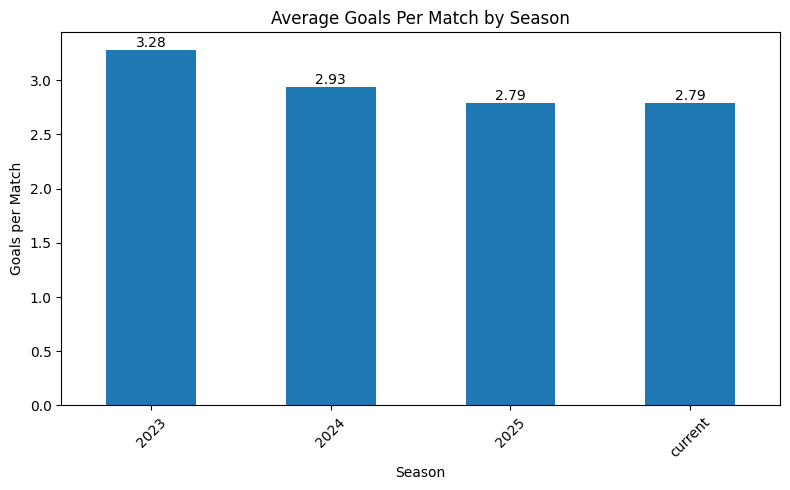

In [ ]:
avg_goals = finished.groupby("season_label")["total_goals"].mean()

ax = avg_goals.plot(kind="bar", figsize=(8,5))

plt.title("Average Goals Per Match by Season")
plt.ylabel("Goals per Match")
plt.xlabel("Season")
plt.xticks(rotation=45)

# Add labels
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [10]:
# Sort chronologically
finished = finished.sort_values("utc_date")

# Compute team average goals scored (rolling mean before match)

finished["home_avg_scored"] = (
    finished.groupby("home_team")["ft_home"]
    .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

finished["home_avg_conceded"] = (
    finished.groupby("home_team")["ft_away"]
    .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

finished["away_avg_scored"] = (
    finished.groupby("away_team")["ft_away"]
    .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

finished["away_avg_conceded"] = (
    finished.groupby("away_team")["ft_home"]
    .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

finished.head()

,match_id,utc_date,status,matchday,home_team_id,home_team,away_team_id,away_team,ft_home,ft_away,...,total_goals,goal_diff_home,result,date,year,month,home_avg_scored,home_avg_conceded,away_avg_scored,away_avg_conceded
0,435943,2023-08-11 19:00:00+00:00,FINISHED,1,328,Burnley FC,65,Manchester City FC,0.0,3.0,...,3.0,-3.0,A,2023-08-11,2023,8,NaN,NaN,NaN,NaN
1,435944,2023-08-12 12:00:00+00:00,FINISHED,1,57,Arsenal FC,351,Nottingham Forest FC,2.0,1.0,...,3.0,1.0,H,2023-08-12,2023,8,NaN,NaN,NaN,NaN
2,435945,2023-08-12 14:00:00+00:00,FINISHED,1,1044,AFC Bournemouth,563,West Ham United FC,1.0,1.0,...,2.0,0.0,D,2023-08-12,2023,8,NaN,NaN,NaN,NaN
3,435946,2023-08-12 14:00:00+00:00,FINISHED,1,397,Brighton & Hove Albion FC,389,Luton Town FC,4.0,1.0,...,5.0,3.0,H,2023-08-12,2023,8,NaN,NaN,NaN,NaN
4,435947,2023-08-12 14:00:00+00:00,FINISHED,1,62,Everton FC,63,Fulham FC,0.0,1.0,...,1.0,-1.0,A,2023-08-12,2023,8,NaN,NaN,NaN,NaN


In [11]:
# Keep only rows where rolling features exist
model_df = finished.dropna(subset=[
    "home_avg_scored",
    "home_avg_conceded",
    "away_avg_scored",
    "away_avg_conceded"
]).copy()

# Encode result
model_df["result_encoded"] = model_df["result"].map({"H": 0, "D": 1, "A": 2})

print("Model dataset shape:", model_df.shape)

Model dataset shape: (1309, 22)


In [12]:
features = [
    "home_avg_scored",
    "home_avg_conceded",
    "away_avg_scored",
    "away_avg_conceded"
]

X = model_df[features]
y = model_df["result_encoded"]

In [13]:
# Temporal train/test split (80/20 by date)
# Time-series data MUST be split chronologically, not randomly
# This prevents data leakage where future information predicts past matches

model_df = model_df.sort_values("utc_date")

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.416

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.77      0.52        90
           1       0.00      0.00      0.00        86
           2       0.45      0.47      0.46        86

    accuracy                           0.42       262
   macro avg       0.28      0.41      0.33       262
weighted avg       0.28      0.42      0.33       262



c:\Users\iliem\DA Projects\PL-football-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\iliem\DA Projects\PL-football-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\iliem\DA Projects\PL-football-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [15]:
# Baseline: always predict most common class
most_common = y_train.mode()[0]
baseline_pred = [most_common] * len(y_test)

print("Baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 3))

Baseline accuracy: 0.344


In [16]:
# Create matchup features
model_df["home_attack_strength"] = (
    model_df["home_avg_scored"] - model_df["away_avg_conceded"]
)

model_df["away_attack_strength"] = (
    model_df["away_avg_scored"] - model_df["home_avg_conceded"]
)

features = [
    "home_avg_scored",
    "home_avg_conceded",
    "away_avg_scored",
    "away_avg_conceded",
    "home_attack_strength",
    "away_attack_strength"
]

X = model_df[features]
y = model_df["result_encoded"]

# Chronological split again
model_df = model_df.sort_values("utc_date")
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Improved Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Improved Accuracy: 0.416

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.77      0.52        90
           1       0.00      0.00      0.00        86
           2       0.45      0.47      0.46        86

    accuracy                           0.42       262
   macro avg       0.28      0.41      0.33       262
weighted avg       0.28      0.42      0.33       262



c:\Users\iliem\DA Projects\PL-football-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\iliem\DA Projects\PL-football-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\iliem\DA Projects\PL-football-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [17]:
# IMPORTANT: Class imbalance observation
# Distribution shows ~43% Home, ~33% Away, ~25% Draws
# Multi-class problems struggle with this imbalance
# Strategy: Simplify to binary classification (Home Win vs Non-Win)
# This improves model performance by addressing skewed class weights


model_df["result"].value_counts(normalize=True)

result
H    0.427044
A    0.326967
D    0.245989
Name: proportion, dtype: float64

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.408

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.79      0.53        90
           1       0.60      0.03      0.07        86
           2       0.41      0.38      0.40        86

    accuracy                           0.41       262
   macro avg       0.47      0.40      0.33       262
weighted avg       0.47      0.41      0.33       262



In [19]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)
y_pred_bal = balanced_model.predict(X_test)

print("Balanced Logistic Accuracy:", round(accuracy_score(y_test, y_pred_bal), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bal))

Balanced Logistic Accuracy: 0.405

Classification Report:

              precision    recall  f1-score   support

           0       0.43      0.51      0.47        90
           1       0.25      0.10      0.15        86
           2       0.43      0.59      0.50        86

    accuracy                           0.40       262
   macro avg       0.37      0.40      0.37       262
weighted avg       0.37      0.40      0.37       262



In [20]:
# Create binary target
model_df["home_win"] = (model_df["result"] == "H").astype(int)

model_df["home_win"].value_counts(normalize=True)

home_win
0    0.572956
1    0.427044
Name: proportion, dtype: float64

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

features = [
    "home_avg_scored",
    "home_avg_conceded",
    "away_avg_scored",
    "away_avg_conceded",
    "home_attack_strength",
    "away_attack_strength"
]

X = model_df[features]
y_binary = model_df["home_win"]

# chronological split
model_df = model_df.sort_values("utc_date")
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y_binary.iloc[:split_index]
y_test = y_binary.iloc[split_index:]

binary_model = LogisticRegression(max_iter=1000)
binary_model.fit(X_train, y_train)

y_pred_bin = binary_model.predict(X_test)

print("Binary Accuracy:", round(accuracy_score(y_test, y_pred_bin), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bin))

Binary Accuracy: 0.618

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       172
           1       0.44      0.42      0.43        90

    accuracy                           0.62       262
   macro avg       0.57      0.57      0.57       262
weighted avg       0.61      0.62      0.62       262



In [22]:
import numpy as np
import matplotlib.pyplot as plt

coefficients = binary_model.coef_[0]
feature_names = features

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient")

importance_df

,Feature,Coefficient
1,home_avg_conceded,-0.415894
2,away_avg_scored,-0.390425
5,away_attack_strength,0.025469
4,home_attack_strength,0.072888
3,away_avg_conceded,0.350095
0,home_avg_scored,0.422983


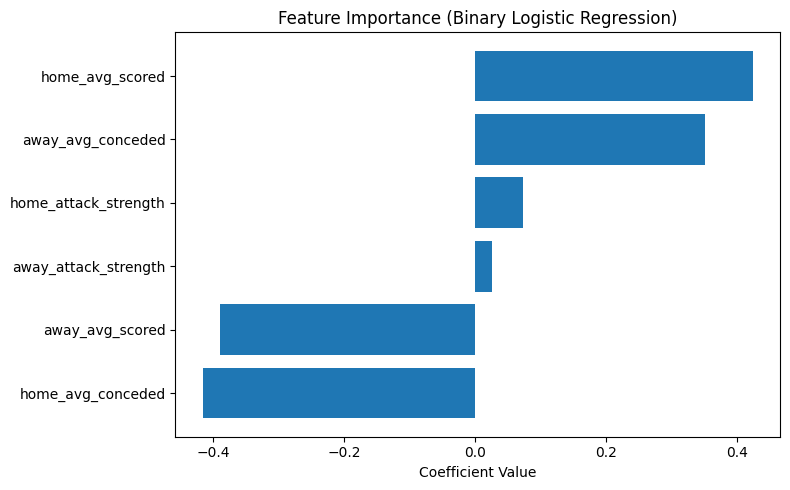

In [23]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Coefficient"])

plt.title("Feature Importance (Binary Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()